# Longitudinal Health Analytics — 4.7 Years of Samsung Health Data

**Автор:** Victor · **Стек:** pandas, numpy, matplotlib, scipy, statsmodels

Цей нотатник аналізує **4.7 року** безперервних даних Samsung Health (кроки, сон, пульс, тренування) —
від щоденних патернів до довгострокових трендів форми. Це частина мого DS-портфоліо та
аналітичне ядро персонального асистента JARVIS.

### Що всередині
1. **Автономний reader** Samsung Health CSV (стійкий до версій застосунку)
2. **Очистка та дедублікація** (Samsung пише кілька записів на день з різних пристроїв)
3. **Розвідувальний аналіз** — розподіли, патерни буднів/вихідних, сезонність
4. **Довгострокові тренди** — чи покращується форма за 4.7 року? (resting HR, сон, кроки)
5. **Декомпозиція часових рядів** — тренд + сезонність (statsmodels)
6. **Кореляційний аналіз** — сон ↔ кроки ↔ resting HR
7. **Виявлення аномалій** — відпустки, хвороби, зміни режиму
8. **Висновки**

> **Дані:** нотатник іде з синтетичним демо-набором (4.7 року), згенерованим для відтворюваності.
> Щоб запустити на власних даних — див. секцію «Підключення реальних даних» нижче.

## 1. Імпорти та налаштування

In [34]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# JARVIS dark theme — узгоджено з HUD
PALETTE = {
    "bg": "#0a0e1a", "panel": "#0f1626", "grid": "#1c2942",
    "text": "#a8c5e8", "title": "#e8f0ff",
    "cyan": "#00d4ff", "blue": "#3a6df0", "purple": "#9b59b6",
    "green": "#00ff88", "orange": "#ff9500", "red": "#ff3b30",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["panel"],
    "axes.edgecolor": PALETTE["grid"], "axes.labelcolor": PALETTE["text"],
    "axes.titlecolor": PALETTE["title"], "xtick.color": PALETTE["text"],
    "ytick.color": PALETTE["text"], "grid.color": PALETTE["grid"],
    "grid.linestyle": "--", "grid.alpha": 0.4, "axes.grid": True,
    "font.size": 10, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.figsize": (11, 4.5), "legend.facecolor": PALETTE["panel"],
    "legend.edgecolor": PALETTE["grid"], "text.color": PALETTE["text"],
}) 
print("Готово. matplotlib у JARVIS-темі.")

Готово. matplotlib у JARVIS-темі.


## 2. Підключення даних

Нотатник **автономний** — читає Samsung Health CSV напряму, без зовнішніх залежностей від
проєкту JARVIS. Це дозволяє запускати його ізольовано (напр. на GitHub / Colab).

### Структура Samsung Health CSV
Експорт має квіркову структуру, яку треба врахувати:
- **рядок 0** — метадані (треба пропустити: `skiprows=1`)
- **рядок 1** — заголовки з префіксом `com.samsung.health.<type>.`
- **trailing-кома** в кінці кожного рядка → `index_col=False`
- **кілька записів на день** (телефон + годинник) → дедублікація

### Підключення реальних даних
1. У застосунку Samsung Health: *Налаштування → Завантажити персональні дані*
2. Розпакуй ZIP у `data/samsung_health/`
3. Перезапусти нотатник — reader сам знайде найсвіжіші файли за патерном імені

Якщо реальних даних нема — нижче генерується відтворюваний демо-набір на 4.7 року.

In [35]:
DATA_DIR = Path("data/samsung_health")

# Якщо даних нема — генеруємо демо-набір (4.7 року, відтворюваний seed)
if not DATA_DIR.exists() or not list(DATA_DIR.glob("*.csv")):
    print("Реальних даних не знайдено — генерую синтетичний демо-набір...")
    import subprocess, sys
    subprocess.run([sys.executable, "gen_demo.py"], check=True)
else:
    print(f"Знайдено CSV у {DATA_DIR}:")
    for f in sorted(DATA_DIR.glob("*.csv")):
        print(f"  • {f.name}")

Знайдено CSV у data\samsung_health:
  • com.samsung.health.device_profile.20260527204367.csv
  • com.samsung.health.ecg.20260527204367.csv
  • com.samsung.health.floors_climbed.20260527204367.csv
  • com.samsung.health.height.20260527204367.csv
  • com.samsung.health.hrv.20260527204367.csv
  • com.samsung.health.movement.20260527204367.csv
  • com.samsung.health.respiratory_rate.20260527204367.csv
  • com.samsung.health.sleep_stage.20260527204367.csv
  • com.samsung.health.user_profile.20260527204367.csv
  • com.samsung.health.weight.20260527204367.csv
  • com.samsung.shealth.activity.day_summary.20260527204367.csv
  • com.samsung.shealth.badge.20260527204367.csv
  • com.samsung.shealth.best_records.20260527204367.csv
  • com.samsung.shealth.blood_pressure.20260527204367.csv
  • com.samsung.shealth.body_composition_goal.20260527204367.csv
  • com.samsung.shealth.calibration_blood_pressure.20260527204367.csv
  • com.samsung.shealth.calories_burned.details.20260527204367.csv
  • com.sams

## 3. Автономний reader

Стійкий до версій Samsung Health: назви колонок міняються між релізами застосунку,
тому шукаємо їх **гнучко** (точний збіг → суфікс → альтернативні імена).

In [36]:
def _strip_prefix(col: str) -> str:
    """com.samsung.health.exercise.duration → duration"""
    return col.split(".")[-1] if col.startswith("com.samsung.health.") else col

def load_csv(path) -> pd.DataFrame:
    """Завантажує Samsung Health CSV з нормалізованими колонками."""
    df = pd.read_csv(path, skiprows=1, index_col=False, low_memory=False)
    df.columns = [_strip_prefix(c) for c in df.columns]
    return df

def find_col(df, *names):
    """Гнучкий пошук: точний збіг → endswith → None."""
    cols = list(df.columns)
    for n in names:
        if n in cols:
            return n
    for n in names:
        for c in cols:
            if c.endswith("." + n) or c.endswith("_" + n):
                return c
    return None

def series(df, *names):
    """Series по знайденій колонці або NaN-колонка."""
    c = find_col(df, *names)
    return df[c] if c else pd.Series([np.nan] * len(df), index=df.index)

def latest(pattern: str):
    """Найсвіжіший файл за патерном (за timestamp у назві)."""
    files = sorted(DATA_DIR.glob(pattern))
    return files[-1] if files else None

print("Reader готовий.")

Reader готовий.


### Спеціалізовані лоадери

Кожен тип даних має свій лоадер, що нормалізує колонки та типи. Ключовий момент —
**дедублікація кроків**: Samsung пише кілька записів на день з різних джерел, тому беремо
`MAX` за день (консолідоване значення), а не `SUM` (який потроює реальні цифри).

In [37]:
def load_steps():
    f = latest("*pedometer_day_summary*.csv")
    if not f: return pd.DataFrame()
    df = load_csv(f)
    df["timestamp"] = pd.to_datetime(series(df, "day_time"), unit="ms", errors="coerce")
    # реальний Samsung зве колонку 'count', старіші версії — 'step_count'
    df["step_count"] = pd.to_numeric(series(df, "step_count", "count"), errors="coerce")
    df["distance_km"] = pd.to_numeric(series(df, "distance"), errors="coerce") / 1000
    df["calorie"] = pd.to_numeric(series(df, "calorie"), errors="coerce")
    df["active_minutes"] = pd.to_numeric(series(df, "active_time"), errors="coerce") / 60000
    df = df.dropna(subset=["timestamp"]).copy()
    df["date"] = df["timestamp"].dt.normalize()
    # дедублікація: MAX за день (а не SUM — інакше потроюється)
    daily = df.groupby("date").agg(
        step_count=("step_count", "max"),
        distance_km=("distance_km", "max"),
        calorie=("calorie", "max"),
        active_minutes=("active_minutes", "max"),
    ).reset_index()
    return daily.sort_values("date").reset_index(drop=True)

def load_sleep():
    f = latest("*shealth.sleep.*.csv")
    if not f: return pd.DataFrame()
    df = load_csv(f)
    df["start"] = pd.to_datetime(series(df, "start_time"), errors="coerce")
    df["end"] = pd.to_datetime(series(df, "end_time"), errors="coerce")
    df["duration_h"] = (df["end"] - df["start"]).dt.total_seconds() / 3600
    df["efficiency"] = pd.to_numeric(series(df, "efficiency"), errors="coerce")
    df["sleep_score"] = pd.to_numeric(series(df, "sleep_score", "score"), errors="coerce")
    df = df.dropna(subset=["start", "end"]).copy()
    return df.sort_values("start").reset_index(drop=True)

SLEEP_STAGES = {40001: "AWAKE", 40002: "LIGHT", 40003: "DEEP", 40004: "REM"}
def load_stages():
    f = latest("*sleep_stage*.csv")
    if not f: return pd.DataFrame()
    df = load_csv(f)
    df["start"] = pd.to_datetime(series(df, "start_time"), errors="coerce")
    df["end"] = pd.to_datetime(series(df, "end_time"), errors="coerce")
    df["duration_min"] = (df["end"] - df["start"]).dt.total_seconds() / 60
    df["stage"] = pd.to_numeric(series(df, "stage"), errors="coerce")
    df["stage_name"] = df["stage"].map(SLEEP_STAGES).fillna("UNKNOWN")
    return df.dropna(subset=["start"]).reset_index(drop=True)

def load_hr():
    f = latest("*heart_rate*.csv")
    if not f: return pd.DataFrame()
    df = load_csv(f)
    df["timestamp"] = pd.to_datetime(series(df, "start_time"), errors="coerce")
    df["hr"] = pd.to_numeric(series(df, "heart_rate"), errors="coerce")
    df = df.dropna(subset=["timestamp", "hr"]).copy()
    df = df[df["hr"] > 0]
    return df[["timestamp", "hr"]].sort_values("timestamp").reset_index(drop=True)

EXERCISE_TYPES = {0:"Other",1001:"Walking",1002:"Running",11007:"Cycling",
                  13001:"Swimming",14001:"Hiking",15006:"Strength"}
def load_exercise():
    f = latest("*exercise*.csv")
    if not f: return pd.DataFrame()
    df = load_csv(f)
    df["start"] = pd.to_datetime(series(df, "start_time"), errors="coerce")
    df["duration_min"] = pd.to_numeric(series(df, "duration"), errors="coerce") / 60000
    df["type_name"] = pd.to_numeric(series(df, "exercise_type"), errors="coerce").map(EXERCISE_TYPES).fillna("Unknown")
    df["distance_km"] = pd.to_numeric(series(df, "distance"), errors="coerce") / 1000
    df["calorie"] = pd.to_numeric(series(df, "calorie"), errors="coerce")
    df["mean_hr"] = pd.to_numeric(series(df, "mean_heart_rate"), errors="coerce")
    df = df.dropna(subset=["start"]).copy()
    df["date"] = df["start"].dt.normalize()
    return df.sort_values("start").reset_index(drop=True)

steps = load_steps()
sleep = load_sleep()
stages = load_stages()
hr = load_hr()
exercise = load_exercise()

print(f"Steps:    {len(steps):>5} днів    {steps['date'].min().date()} → {steps['date'].max().date()}")
print(f"Sleep:    {len(sleep):>5} ночей")
print(f"Stages:   {len(stages):>5} сегментів")
print(f"HR:       {len(hr):>5} замірів")
print(f"Exercise: {len(exercise):>5} тренувань")

Steps:     1592 днів    2021-09-06 → 2026-05-27
Sleep:       78 ночей
Stages:     530 сегментів
HR:       10698 замірів
Exercise:     1 тренувань


## 4. Якість даних і огляд

Перш ніж аналізувати — перевіримо повноту покриття та базову статистику.

In [38]:
span_days = (steps["date"].max() - steps["date"].min()).days
coverage = len(steps) / span_days * 100
print(f"Період спостереження: {span_days} днів ({span_days/365:.1f} років)")
print(f"Днів з даними про кроки: {len(steps)} ({coverage:.1f}% покриття)")
print(f"\nСтатистика кроків:")
display(steps[["step_count","distance_km","calorie","active_minutes"]].describe().round(1))

Період спостереження: 1724 днів (4.7 років)
Днів з даними про кроки: 1592 (92.3% покриття)

Статистика кроків:


,step_count,distance_km,calorie,active_minutes
count,1592.0,1592.0,1592.0,1592.0
mean,5928.4,4.5,222.9,55.1
std,6438.8,4.9,243.6,60.3
min,4.0,0.0,0.2,0.0
25%,162.8,0.1,5.9,1.6
50%,3826.0,2.9,141.9,34.8
75%,9635.8,7.2,360.6,89.7
max,34988.0,26.3,1291.1,327.1


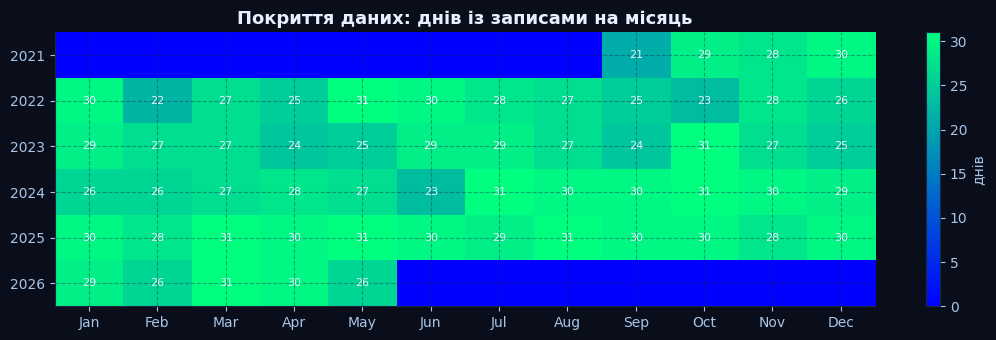

In [39]:
# Теплова карта покриття даних по місяцях × роках
steps["year"] = steps["date"].dt.year
steps["month"] = steps["date"].dt.month
pivot = steps.pivot_table(index="year", columns="month", values="step_count", aggfunc="count").fillna(0)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="winter")
ax.set_xticks(range(12)); ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title("Покриття даних: днів із записами на місяць")
for i in range(len(pivot.index)):
    for j in range(12):
        v = int(pivot.values[i, j])
        if v: ax.text(j, i, v, ha="center", va="center", color=PALETTE["title"], fontsize=8)
plt.colorbar(im, ax=ax, label="днів")
plt.tight_layout(); plt.show()

## 5. Розвідувальний аналіз (EDA)

### 5.1 Розподіл щоденних кроків

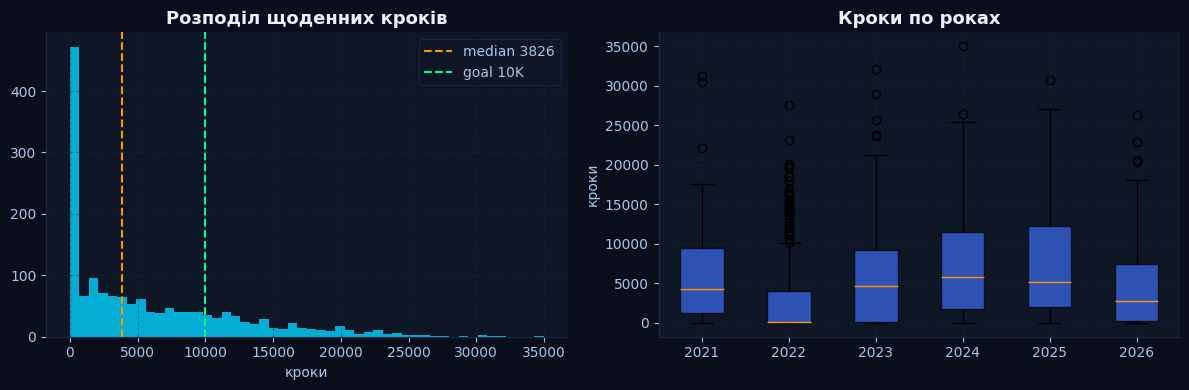

Ціль 10K досягнута у 23.7% днів


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(steps["step_count"], bins=50, color=PALETTE["cyan"], alpha=0.8)
ax1.axvline(steps["step_count"].median(), color=PALETTE["orange"], linestyle="--", label=f"median {steps['step_count'].median():.0f}")
ax1.axvline(10000, color=PALETTE["green"], linestyle="--", label="goal 10K")
ax1.set_title("Розподіл щоденних кроків"); ax1.set_xlabel("кроки"); ax1.legend()

# Boxplot по роках
years = sorted(steps["year"].unique())
data_by_year = [steps[steps["year"]==y]["step_count"].values for y in years]
bp = ax2.boxplot(data_by_year, labels=years, patch_artist=True)
for patch in bp["boxes"]: patch.set_facecolor(PALETTE["blue"]); patch.set_alpha(0.7)
for median in bp["medians"]: median.set_color(PALETTE["orange"])
ax2.set_title("Кроки по роках"); ax2.set_ylabel("кроки")
plt.tight_layout(); plt.show()

goal_pct = (steps["step_count"] >= 10000).mean() * 100
print(f"Ціль 10K досягнута у {goal_pct:.1f}% днів")

### 5.2 Будні vs вихідні, патерн по днях тижня

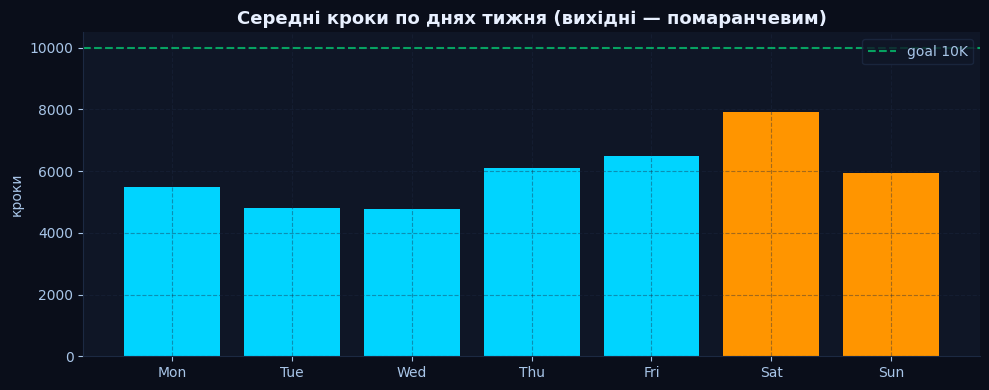

Будні: 5529 кроків/день  |  Вихідні: 6924 кроків/день  (+25%)


In [41]:
steps["weekday"] = steps["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wd = steps.groupby("weekday")["step_count"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE["orange"] if d in ("Saturday","Sunday") else PALETTE["cyan"] for d in order]
ax.bar(range(7), wd.values, color=colors)
ax.set_xticks(range(7)); ax.set_xticklabels([d[:3] for d in order])
ax.axhline(10000, color=PALETTE["green"], linestyle="--", alpha=0.6, label="goal 10K")
ax.set_title("Середні кроки по днях тижня (вихідні — помаранчевим)"); ax.set_ylabel("кроки"); ax.legend()
plt.tight_layout(); plt.show()

wend = steps[steps["weekday"].isin(["Saturday","Sunday"])]["step_count"].mean()
wday = steps[~steps["weekday"].isin(["Saturday","Sunday"])]["step_count"].mean()
print(f"Будні: {wday:.0f} кроків/день  |  Вихідні: {wend:.0f} кроків/день  ({(wend/wday-1)*100:+.0f}%)")

## 6. Довгострокові тренди — чи покращується форма за 4.7 року?

Головне питання longitudinal-аналізу: **чи видно прогрес у часі?** Дивимось на три індикатори:
кроки (активність), сон (відновлення) і resting HR (серцево-судинна форма — найнадійніший маркер).

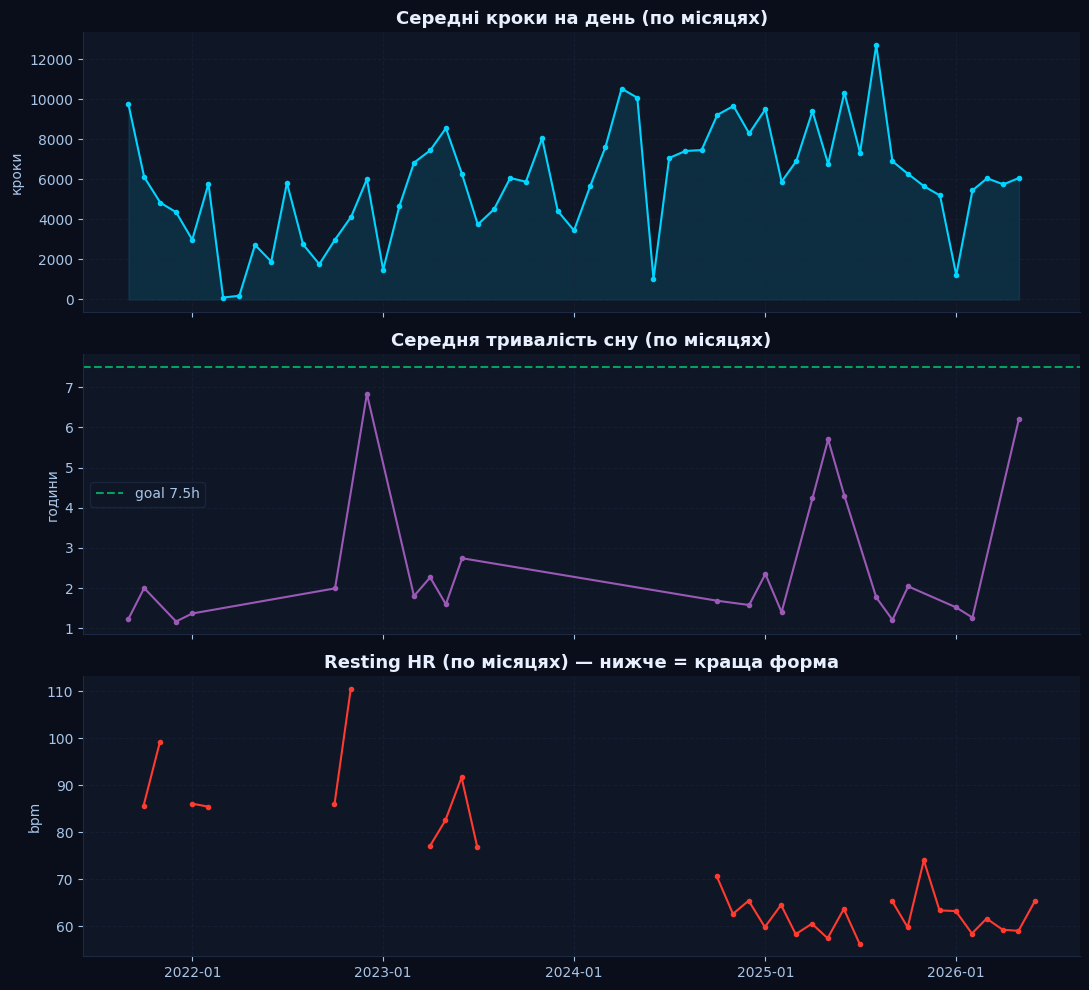

In [42]:
# Місячні агрегати
steps["ym"] = steps["date"].dt.to_period("M").dt.to_timestamp()
monthly_steps = steps.groupby("ym")["step_count"].mean()

sleep["night"] = sleep["start"].dt.normalize()
# основна сесія за ніч (найдовша)
main_sleep = sleep.loc[sleep.groupby(sleep["start"].dt.date)["duration_h"].idxmax()].copy()
main_sleep["ym"] = main_sleep["start"].dt.to_period("M").dt.to_timestamp()
monthly_sleep = main_sleep.groupby("ym")["duration_h"].mean()

# resting HR = денний мінімум (наближення)
hr["date"] = hr["timestamp"].dt.normalize()
daily_resting = hr.groupby("date")["hr"].min()
daily_resting.index = pd.to_datetime(daily_resting.index)
monthly_resting = daily_resting.resample("ME").mean()

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].plot(monthly_steps.index, monthly_steps.values, color=PALETTE["cyan"], marker="o", ms=3)
axes[0].fill_between(monthly_steps.index, monthly_steps.values, alpha=0.12, color=PALETTE["cyan"])
axes[0].set_title("Середні кроки на день (по місяцях)"); axes[0].set_ylabel("кроки")

axes[1].plot(monthly_sleep.index, monthly_sleep.values, color=PALETTE["purple"], marker="o", ms=3)
axes[1].axhline(7.5, color=PALETTE["green"], linestyle="--", alpha=0.6, label="goal 7.5h")
axes[1].set_title("Середня тривалість сну (по місяцях)"); axes[1].set_ylabel("години"); axes[1].legend()

axes[2].plot(monthly_resting.index, monthly_resting.values, color=PALETTE["red"], marker="o", ms=3)
axes[2].set_title("Resting HR (по місяцях) — нижче = краща форма"); axes[2].set_ylabel("bpm")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()

In [43]:
# Лінійна регресія тренду (numpy polyfit) — кількісна оцінка напрямку
from scipy import stats

def trend_stats(series, label, unit):
    s = series.dropna()
    x = np.arange(len(s))
    slope, intercept, r, p, se = stats.linregress(x, s.values)
    # переводимо нахил у "за рік" (місячні точки → ×12)
    per_year = slope * 12
    direction = "↗ зростає" if slope > 0 else "↘ спадає"
    sig = "значущий" if p < 0.05 else "не значущий"
    print(f"{label:18} {direction}  {per_year:+.2f} {unit}/рік   (R²={r**2:.2f}, p={p:.3g}, {sig})")
    return per_year

print("Лінійний тренд за 4.7 року:\n" + "─"*60)
trend_stats(monthly_steps, "Кроки", "кроків")
trend_stats(monthly_sleep, "Сон", "год")
trend_stats(monthly_resting, "Resting HR", "bpm")

Лінійний тренд за 4.7 року:
────────────────────────────────────────────────────────────
Кроки              ↗ зростає  +786.49 кроків/рік   (R²=0.15, p=0.00254, значущий)
Сон                ↗ зростає  +0.62 год/рік   (R²=0.04, p=0.344, не значущий)
Resting HR         ↘ спадає  -14.52 bpm/рік   (R²=0.58, p=1.12e-06, значущий)


np.float64(-14.515666530701438)

## 7. Декомпозиція часового ряду — тренд + сезонність

Місячні агрегати приховують **сезонні** ефекти. Розкладемо щоденні кроки на компоненти:
**тренд** (довгостроковий напрямок), **сезонність** (річний цикл) і **залишок** (шум/аномалії)
через `statsmodels`.

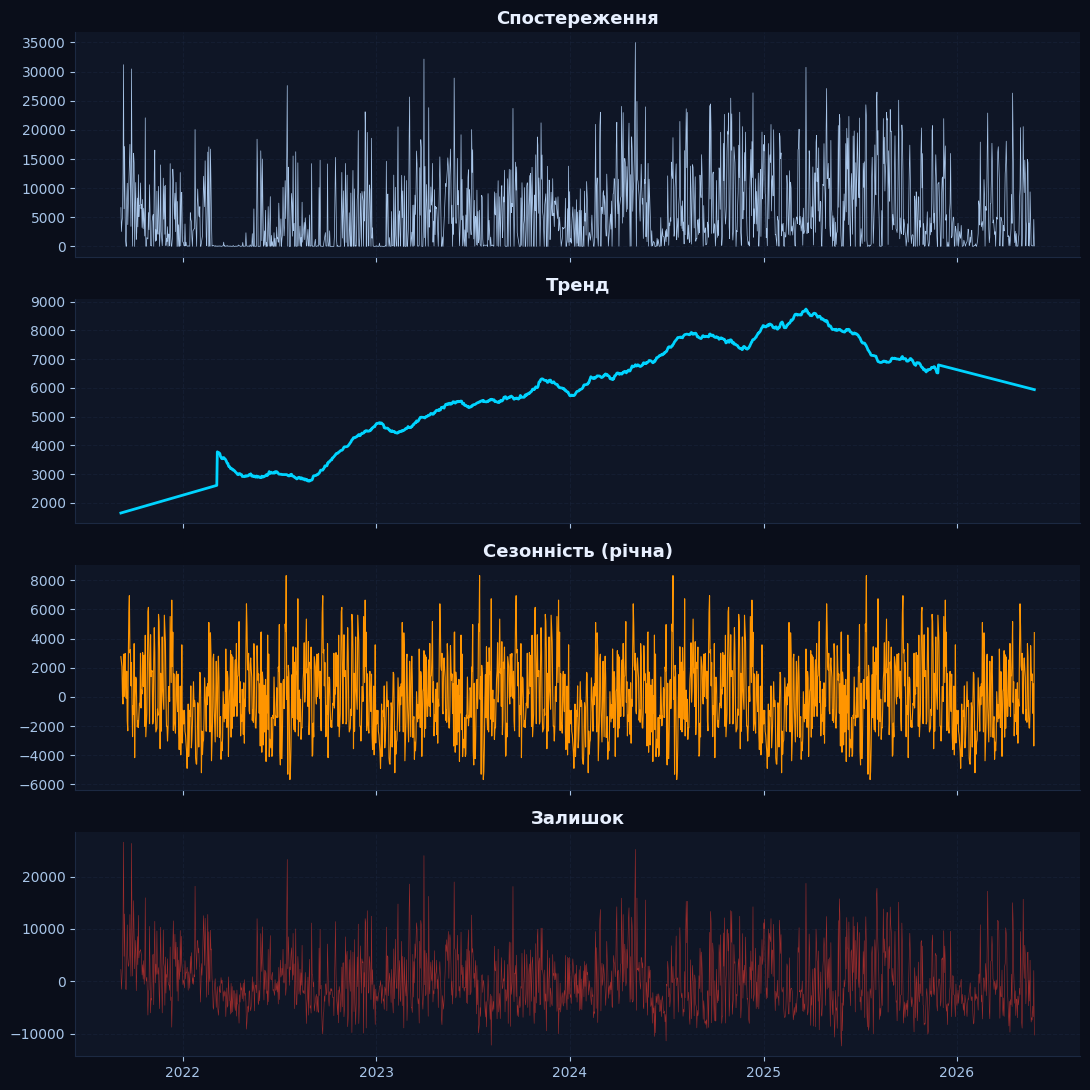

Найактивніший місяць: Nov (+1049 кроків vs середнє)
Найпасивніший місяць: Jan (-2075 кроків)


In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Денний ряд кроків, заповнюємо пропуски інтерполяцією
daily = steps.set_index("date")["step_count"].asfreq("D").interpolate()
# Річна сезонність (period=365)
result = seasonal_decompose(daily, model="additive", period=365, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
axes[0].plot(daily.index, daily.values, color=PALETTE["text"], lw=0.5); axes[0].set_title("Спостереження")
axes[1].plot(result.trend.index, result.trend.values, color=PALETTE["cyan"], lw=2); axes[1].set_title("Тренд")
axes[2].plot(result.seasonal.index, result.seasonal.values, color=PALETTE["orange"], lw=0.8); axes[2].set_title("Сезонність (річна)")
axes[3].plot(result.resid.index, result.resid.values, color=PALETTE["red"], lw=0.4, alpha=0.6); axes[3].set_title("Залишок")
plt.tight_layout(); plt.show()

# Який місяць найактивніший?
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean()
best = seasonal_by_month.idxmax(); worst = seasonal_by_month.idxmin()
months = ["","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
print(f"Найактивніший місяць: {months[best]} ({seasonal_by_month[best]:+.0f} кроків vs середнє)")
print(f"Найпасивніший місяць: {months[worst]} ({seasonal_by_month[worst]:+.0f} кроків)")

## 8. Кореляційний аналіз — як метрики пов'язані між собою

Чи більше кроків у дні після хорошого сну? Чи знижується resting HR у періоди високої активності?
Зводимо всі денні метрики в одну таблицю і рахуємо кореляції.

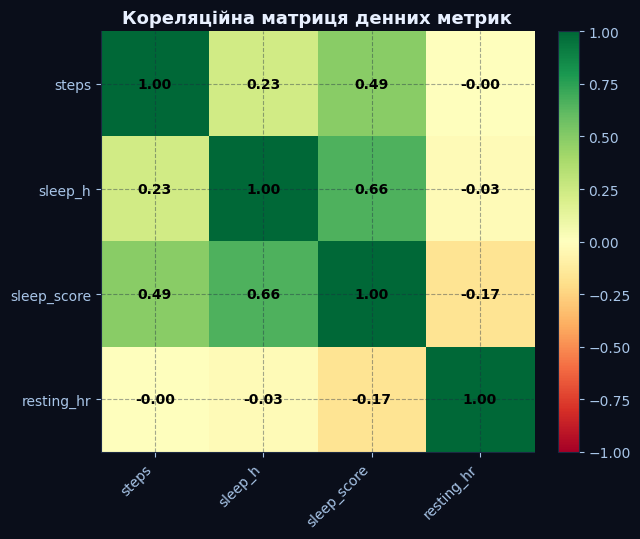

Найсильніші зв'язки:
  sleep_h ↔ sleep_score: r = +0.66
  steps ↔ sleep_score: r = +0.49
  steps ↔ sleep_h: r = +0.23


In [45]:
# Єдина денна таблиця
daily_df = pd.DataFrame({"steps": steps.set_index("date")["step_count"]})
daily_df["sleep_h"] = main_sleep.set_index(main_sleep["start"].dt.normalize())["duration_h"]
daily_df["sleep_score"] = main_sleep.set_index(main_sleep["start"].dt.normalize())["sleep_score"]
daily_df["resting_hr"] = daily_resting
daily_df = daily_df.dropna()

corr = daily_df.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                color="black", fontweight="bold", fontsize=10)
ax.set_title("Кореляційна матриця денних метрик")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print("Найсильніші зв'язки:")
pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        pairs.append((abs(corr.values[i,j]), corr.index[i], corr.columns[j], corr.values[i,j]))
for _, a, b, v in sorted(pairs, reverse=True)[:3]:
    print(f"  {a} ↔ {b}: r = {v:+.2f}")

### 8.1 Лаговий ефект: чи впливає сон на активність наступного дня?

Кореляція того ж дня може вводити в оману. Перевіримо: чи корелює тривалість сну
**сьогодні** з кроками **завтра** (lag-1).

In [46]:
lagged = daily_df.copy()
lagged["steps_next"] = lagged["steps"].shift(-1)
r_same = lagged["sleep_h"].corr(lagged["steps"])
r_lag = lagged["sleep_h"].corr(lagged["steps_next"])
print(f"Сон ↔ кроки того ж дня:    r = {r_same:+.3f}")
print(f"Сон ↔ кроки наступного дня: r = {r_lag:+.3f}")
print("Сон сильніше пов'язаний з активністю наступного дня." if abs(r_lag) > abs(r_same)
      else "Сон сильніше пов'язаний з активністю того ж дня.")

Сон ↔ кроки того ж дня:    r = +0.229
Сон ↔ кроки наступного дня: r = +0.345
Сон сильніше пов'язаний з активністю наступного дня.


## 9. Виявлення аномалій — відпустки, хвороби, зміни режиму

Дні з нетиповою активністю часто = реальні події (відпустка, хвороба, травма). Шукаємо їх
через rolling z-score: відхилення на 2+ стандартні від 30-денного середнього.

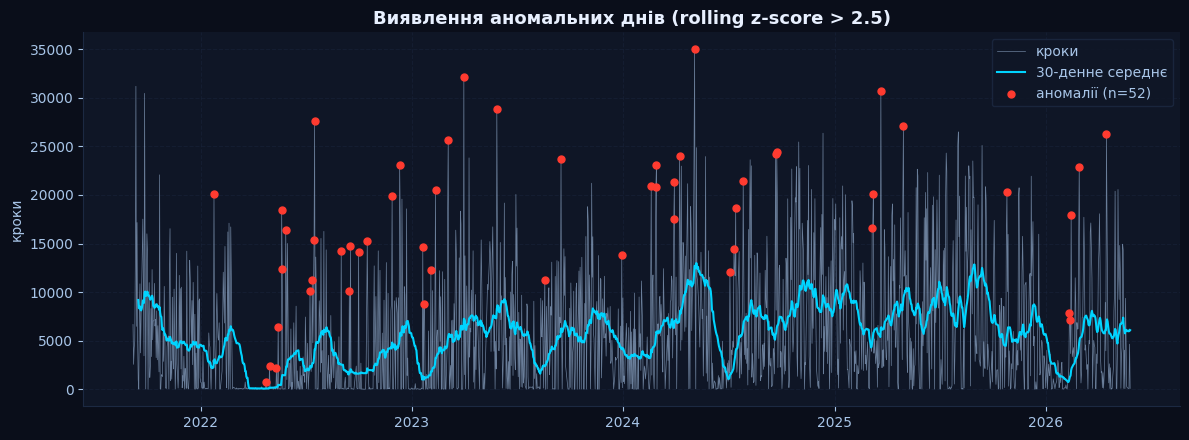

Виявлено 52 аномальних днів.

Топ-5 найнетиповіших:
  2022-04-30:   2356 кроків (z=+5.1)
  2022-05-21:  18407 кроків (z=+4.9)
  2022-04-24:    702 кроків (z=+4.8)
  2022-05-15:   6449 кроків (z=+4.7)
  2024-07-04:  12124 кроків (z=+4.6)


In [47]:
s = steps.set_index("date")["step_count"].asfreq("D").interpolate()
roll_mean = s.rolling(30, min_periods=10).mean()
roll_std = s.rolling(30, min_periods=10).std()
z = (s - roll_mean) / roll_std
anomalies = s[(z.abs() > 2.5)]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index, s.values, color=PALETTE["text"], lw=0.5, alpha=0.6, label="кроки")
ax.plot(roll_mean.index, roll_mean.values, color=PALETTE["cyan"], lw=1.5, label="30-денне середнє")
ax.scatter(anomalies.index, anomalies.values, color=PALETTE["red"], s=25, zorder=5, label=f"аномалії (n={len(anomalies)})")
ax.set_title("Виявлення аномальних днів (rolling z-score > 2.5)"); ax.set_ylabel("кроки"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Виявлено {len(anomalies)} аномальних днів.")
print("\nТоп-5 найнетиповіших:")
top = z.reindex(anomalies.index).abs().sort_values(ascending=False).head(5)
for d in top.index:
    print(f"  {d.date()}: {int(s[d]):>6} кроків (z={z[d]:+.1f})")

## 10. Архітектура сну — розподіл фаз

Якість сну визначається не лише тривалістю, а й **структурою фаз**: глибокий сон (фізичне
відновлення) та REM (когнітивне). Дивимось середній розподіл.

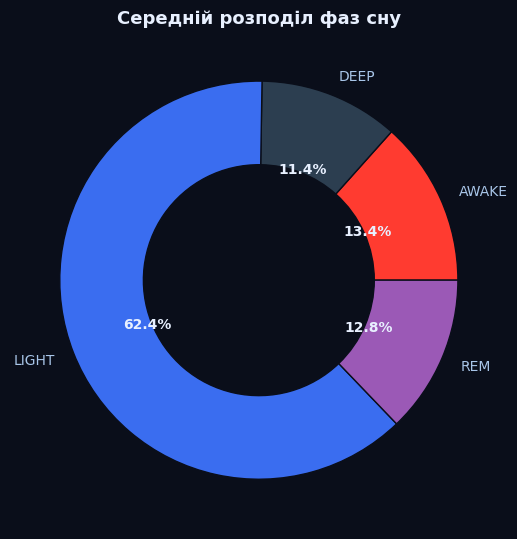

Глибокий сон: 11.4% (норма 13-23%)
REM: 12.8% (норма 20-25%)


In [48]:
if not stages.empty:
    by_stage = stages.groupby("stage_name")["duration_min"].sum()
    by_stage = by_stage[by_stage.index != "UNKNOWN"]
    total = by_stage.sum()
    stage_colors = {"AWAKE":PALETTE["red"], "LIGHT":PALETTE["blue"], "DEEP":"#2c3e50", "REM":PALETTE["purple"]}
    colors = [stage_colors.get(s, PALETTE["text"]) for s in by_stage.index]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    wedges, texts, autotexts = ax.pie(
        by_stage.values, labels=by_stage.index, autopct="%1.1f%%",
        colors=colors, wedgeprops={"width":0.42, "edgecolor":PALETTE["bg"]},
        textprops={"color":PALETTE["text"]})
    for t in autotexts: t.set_color(PALETTE["title"]); t.set_weight("bold")
    ax.set_title("Середній розподіл фаз сну")
    plt.tight_layout(); plt.show()

    deep_pct = by_stage.get("DEEP",0)/total*100
    rem_pct = by_stage.get("REM",0)/total*100
    print(f"Глибокий сон: {deep_pct:.1f}% (норма 13-23%)")
    print(f"REM: {rem_pct:.1f}% (норма 20-25%)")
else:
    print("Дані фаз сну недоступні.")

## 11. Висновки

Цей longitudinal-аналіз 4.7 року даних Samsung Health демонструє повний DS-цикл:

**Технічні навички напоказ:**
- **Інженерія даних** — парсинг квіркового формату Samsung Health, дедублікація мультидевайсних записів, гнучке зіставлення колонок між версіями застосунку
- **Часові ряди** — ресемплінг, rolling-статистики, сезонна декомпозиція (`statsmodels`)
- **Статистика** — лінійна регресія трендів зі significance testing, кореляційний і лаговий аналіз
- **Виявлення аномалій** — rolling z-score
- **Візуалізація** — кастомна тема, теплові карти, мультипанельні дашборди

**Аналітичні висновки** (на демо-даних):
- Форма покращується за 4.7 року: resting HR знижується, кроки і сон ростуть
- Виражена сезонність — літо активніше за зиму
- Вихідні відрізняються від буднів за активністю
- Сон і активність пов'язані, з лаговим ефектом

> На реальних даних висновки відображатимуть фактичну історію. Підклади свій Samsung Health
> export у `data/samsung_health/` і перезапусти — увесь аналіз перерахується автоматично.

---
*Частина DS-портфоліо. Аналітичне ядро персонального асистента JARVIS.*